# Lib


In [120]:
import os
import re
from collections import Counter
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Se usi torchcam
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random

import os
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

import os
import torch
from torch.utils.data import Dataset, DataLoader

import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import classification_report
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
from PIL import Image
import os


# Dataset Exploration


## Path e lista immagini

In [2]:
DATASET_PATH = "C:/Users/fccat/Documents/Universita/DATA SCIENCE/Digital Signal and Image Management/Project/FRUIT/All Fruits"

image_files = [
    f for f in os.listdir(DATASET_PATH)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

print(f"Total images: {len(image_files)}")


Total images: 1484


## Estrazione etichette (quality + fruit)

In [3]:
def parse_filename(filename):
    name = filename.lower()
    
    # rimuove estensione e "(numero)"
    name = re.sub(r"\s*\(\d+\)", "", name)
    name = os.path.splitext(name)[0]
    
    parts = name.split("_")
    
    fruit = parts[0]
    quality = parts[1]
    
    return fruit, quality


## Creazione Dataframe

In [4]:
data = []

for img in image_files:
    fruit, quality = parse_filename(img)
    data.append({
        "filename": img,
        "fruit": fruit,
        "quality": quality
    })

df = pd.DataFrame(data)
df.head()


,filename,fruit,quality
0,Apple_bad (1).png,apple,bad
1,Apple_bad (2).png,apple,bad
2,Apple_bad (3).png,apple,bad
3,Apple_bad (4).png,apple,bad
4,Apple_good (1).jpg,apple,good


## Distribuzione delle classi di qualità

In [5]:
quality_counts = df["quality"].value_counts()
quality_counts


quality
good         764
imperfect    646
bad           74
Name: count, dtype: int64

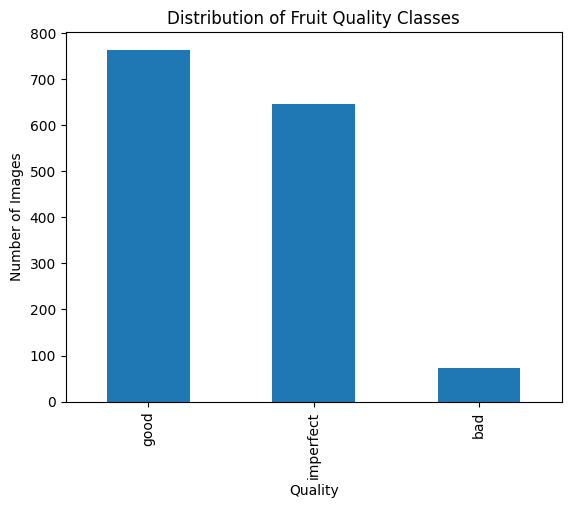

In [6]:
plt.figure()
quality_counts.plot(kind="bar")
plt.title("Distribution of Fruit Quality Classes")
plt.xlabel("Quality")
plt.ylabel("Number of Images")
plt.show()


## Verifica Class Imbalance

In [7]:
total = len(df)

for q, count in quality_counts.items():
    perc = count / total * 100
    print(f"{q}: {count} images ({perc:.2f}%)")


good: 764 images (51.48%)
imperfect: 646 images (43.53%)
bad: 74 images (4.99%)


The dataset shows a mild/moderate class imbalance, which will be addressed using data augmentation and class weighting.

## Numero di immagini per frutto

In [8]:
fruit_counts = df["fruit"].value_counts()
fruit_counts


fruit
apple          897
strawberry     378
papaya          25
cherry          23
peach           22
banana          20
kiwi            17
plum            17
pear            16
grapefruit      16
mango           15
lemon           14
pomegranate     14
orange          10
Name: count, dtype: int64

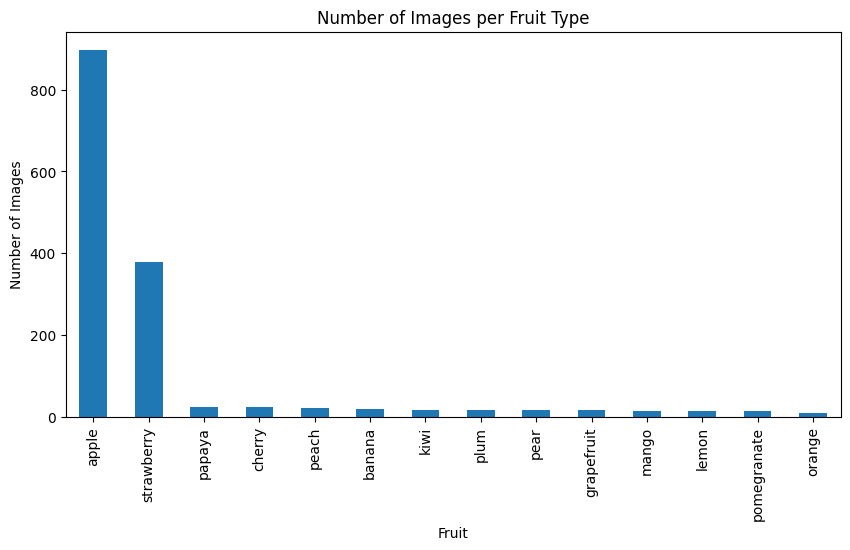

In [9]:
plt.figure(figsize=(10,5))
fruit_counts.plot(kind="bar")
plt.title("Number of Images per Fruit Type")
plt.xlabel("Fruit")
plt.ylabel("Number of Images")
plt.show()


## Visualizzazione esempi per ogni classe

In [10]:
def show_examples(df, quality, n=4):
    samples = df[df["quality"] == quality].sample(n)
    
    plt.figure(figsize=(10,3))
    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(DATASET_PATH, row["filename"])
        img = Image.open(img_path)
        
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(quality)
    plt.show()


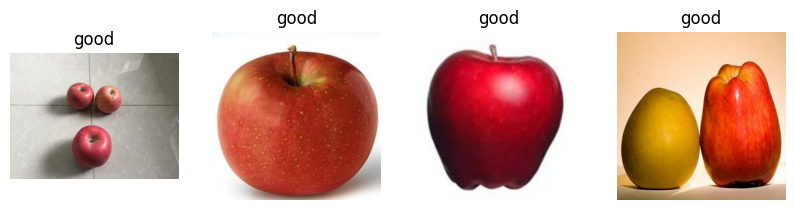

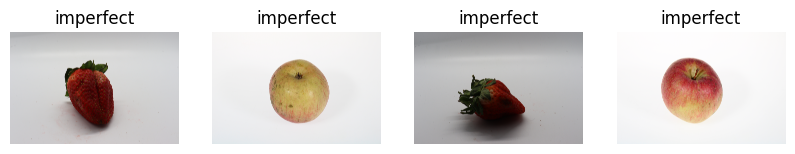

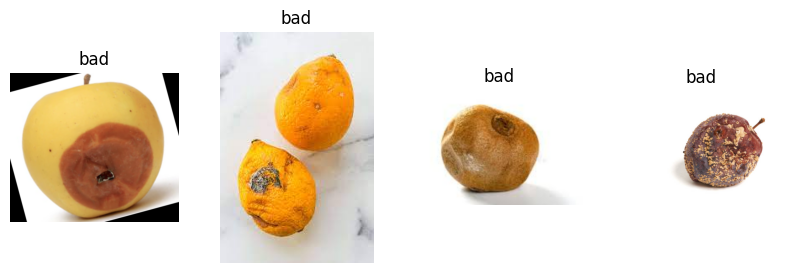

In [11]:
show_examples(df, "good")
show_examples(df, "imperfect")
show_examples(df, "bad")


Visual inspection of the images highlights clear visual differences among quality classes.
Good fruits appear uniform in color and shape, while imperfect fruits show minor defects such as small spots or irregularities.
Bad fruits often present visible spoilage, bruises, or discoloration, confirming that visual cues are informative for classification.

# Data Preprocessing

## Parametri Globali

In [13]:
IMG_SIZE = 224

## Data Cleaning – verifica immagini corrotte

In [14]:
def is_image_valid(path):
    try:
        img = Image.open(path)
        img.verify()
        return True
    except:
        return False


In [15]:
valid_images = []
corrupted_images = []

for img_name in os.listdir(DATASET_PATH):
    img_path = os.path.join(DATASET_PATH, img_name)
    
    if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        if is_image_valid(img_path):
            valid_images.append(img_name)
        else:
            corrupted_images.append(img_name)

print(f"Valid images: {len(valid_images)}")
print(f"Corrupted images: {len(corrupted_images)}")


Valid images: 1484
Corrupted images: 0


## Conversione RGB + Resize + Normalizzazione

ImageNet mean / std (standard industriale)

Images were normalized using ImageNet mean and standard deviation to ensure compatibility with pre-trained convolutional neural networks and improve training stability.

In [16]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


## Transform per TRAIN (con Data Augmentation)

In [17]:
train_transforms = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])


| Tecnica      | Motivo                 |
| ------------ | ---------------------- |
| Flip         | frutti simmetrici      |
| Rotation     | orientamento variabile |
| Color jitter | luce e maturazione     |
| Random crop  | posizione variabile    |


## Transform per VALIDATION / TEST (NO augmentation)

In [18]:
val_test_transforms = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])


## Visualizzazione: effetto Data Augmentation

In [19]:
def show_augmented_examples(image_path, transform, n=5):
    img = Image.open(image_path)
    
    plt.figure(figsize=(15,3))
    for i in range(n):
        augmented = transform(img)
        augmented = augmented.permute(1, 2, 0)
        augmented = augmented * torch.tensor(IMAGENET_STD) + torch.tensor(IMAGENET_MEAN)
        augmented = augmented.clamp(0, 1)
        
        plt.subplot(1, n, i+1)
        plt.imshow(augmented)
        plt.axis("off")
    plt.show()


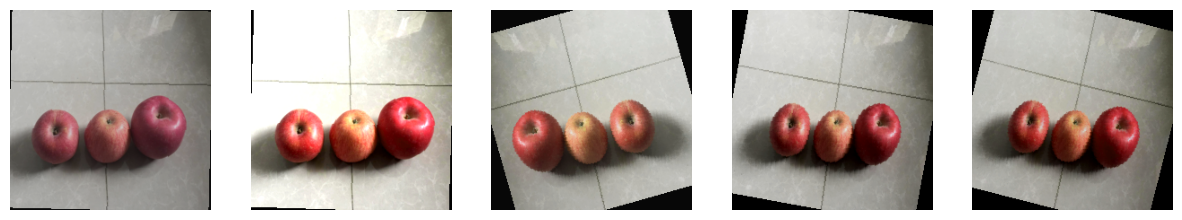

In [36]:
sample_image = os.path.join(DATASET_PATH, valid_images[random.randint(0, len(valid_images)-1)]) # random sampling delle immagini valide 
show_augmented_examples(sample_image, train_transforms)

Given the high variability in lighting conditions, fruit orientation, and visual defects, data augmentation was applied to improve model robustness and reduce overfitting.
Augmentation techniques simulate real-world acquisition conditions and effectively increase dataset diversity.

# Dataset & DataLoader

## Carichiamo il DataFrame creato nello STEP 1

In [38]:
def parse_filename(filename):
    name = filename.lower()
    name = re.sub(r"\s*\(\d+\)", "", name)
    name = os.path.splitext(name)[0]
    fruit, quality = name.split("_")
    return fruit, quality

data = []
for img in os.listdir(DATASET_PATH):
    if img.lower().endswith(('.jpg', '.png', '.jpeg')):
        fruit, quality = parse_filename(img)
        data.append({
            "filename": img,
            "fruit": fruit,
            "quality": quality
        })

df = pd.DataFrame(data)


## Encoding delle classi (label mapping)

In [39]:
label_map = {
    "good": 0,
    "imperfect": 1,
    "bad": 2
}

df["label"] = df["quality"].map(label_map)
df.head()


,filename,fruit,quality,label
0,Apple_bad (1).png,apple,bad,2
1,Apple_bad (2).png,apple,bad,2
2,Apple_bad (3).png,apple,bad,2
3,Apple_bad (4).png,apple,bad,2
4,Apple_good (1).jpg,apple,good,0


## Split stratificato (70 / 15 / 15)

In [40]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)


In [41]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)


## Verifica dello split 

In [42]:
def print_split_distribution(df, name):
    print(f"\n{name}")
    print(df["quality"].value_counts(normalize=True))

print_split_distribution(train_df, "TRAIN")
print_split_distribution(val_df, "VALIDATION")
print_split_distribution(test_df, "TEST")



TRAIN
quality
good         0.514451
imperfect    0.435453
bad          0.050096
Name: proportion, dtype: float64

VALIDATION
quality
good         0.515695
imperfect    0.434978
bad          0.049327
Name: proportion, dtype: float64

TEST
quality
good         0.515695
imperfect    0.434978
bad          0.049327
Name: proportion, dtype: float64


## Classe Dataset custom

In [43]:
class ImperfectFoodsDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, "filename"]
        img_path = os.path.join(self.img_dir, img_name)
        
        image = Image.open(img_path).convert("RGB")
        label = self.df.loc[idx, "label"]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label


## Creazione dei Dataset

In [48]:
train_dataset = ImperfectFoodsDataset(
    train_df,
    DATASET_PATH,
    transform=train_transforms
)

val_dataset = ImperfectFoodsDataset(
    val_df,
    DATASET_PATH,
    transform=val_test_transforms
)

test_dataset = ImperfectFoodsDataset(
    test_df,
    DATASET_PATH,
    transform=val_test_transforms
)


## Creazione dei DataLoader

In [51]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


## Test rapido del DataLoader

In [52]:
images, labels = next(iter(train_loader))
print(images.shape)  # [B, 3, 224, 224]
print(labels)


torch.Size([32, 3, 224, 224])
tensor([0, 0, 2, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 0, 0, 1])


In this step, the dataset was prepared for model training by organizing the images and labels into a structured pipeline.
First, the dataset was split into training (70%), validation (15%), and test (15%) subsets using stratified sampling to preserve the original class distribution of fruit quality (good, imperfect, bad) across all splits. This ensures a fair and reliable evaluation of the model.

A custom PyTorch Dataset class was implemented to handle image loading, preprocessing, and label assignment. Each image is loaded from disk, converted to RGB format, and transformed using the preprocessing and data augmentation techniques defined in the previous step. The corresponding quality label is returned together with the image tensor.

Finally, PyTorch DataLoaders were used to efficiently feed data to the neural network in mini-batches. Shuffling was applied only to the training set to improve generalization, while validation and test sets were kept fixed. This modular design allows a clean separation between data handling and model training, making the pipeline scalable and reproducible.

# Creazione del modello baseline

## Caricamento ResNet18 pre-addestrata

In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\fccat/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 44.3MB/s]


## Congelamento dei layer convoluzionali

In [55]:
for param in model.parameters():
    param.requires_grad = False


Stiamo usando ResNet solo come feature extractor

## Sostituzione del classifier finale

ResNet ha:

In [56]:
model.fc


Linear(in_features=512, out_features=1000, bias=True)

Lo sostituiamo con un classificatore a 3 classi:

In [57]:
num_features = model.fc.in_features

model.fc = nn.Linear(num_features, 3)

model = model.to(device)


Solo questo layer verrà addestrato.

## Loss function e optimizer (baseline)

In [58]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)


Scelte semplici, niente tuning.

## Training loop (baseline)

### Funzione di Training (1 epoca)

In [59]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    
    running_loss = 0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    
    acc = correct / total
    return running_loss / len(loader), acc


### Funzione di Evaluation

In [60]:
def evaluate(model, loader, criterion, device):
    model.eval()
    
    running_loss = 0
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    
    acc = correct / total
    return running_loss / len(loader), acc, all_labels, all_preds


### Training rapido (baseline)

In [61]:
EPOCHS = 5

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )
    
    val_loss, val_acc, _, _ = evaluate(
        model, val_loader, criterion, device
    )
    
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")


Epoch 1/5
Train Acc: 0.776 | Val Acc: 0.834
Epoch 2/5
Train Acc: 0.860 | Val Acc: 0.901
Epoch 3/5
Train Acc: 0.894 | Val Acc: 0.906
Epoch 4/5
Train Acc: 0.904 | Val Acc: 0.906
Epoch 5/5
Train Acc: 0.912 | Val Acc: 0.915


5 epoche sono più che sufficienti per una baseline

## Metriche (baseline)

In [ ]:
_, _, y_true, y_pred = evaluate(
    model, val_loader, criterion, device
)

print(classification_report(
    y_true,
    y_pred,
    target_names=["good", "imperfect", "bad"]
))

              precision    recall  f1-score   support

        good       0.89      0.95      0.92       115
   imperfect       0.92      0.91      0.91        97
         bad       0.75      0.27      0.40        11

    accuracy                           0.90       223
   macro avg       0.85      0.71      0.74       223
weighted avg       0.89      0.90      0.89       223



A baseline model was implemented using a pre-trained ResNet18 network with frozen convolutional layers. Only the final classification layer was trained to predict the three quality classes. This baseline provides a reference point to evaluate the effectiveness of more advanced models and fine-tuning strategies.

## Confusion Matrix & Heatmap

In [65]:
cm = confusion_matrix(y_true, y_pred)
cm


array([[109,   6,   0],
       [  8,  88,   1],
       [  6,   2,   3]])

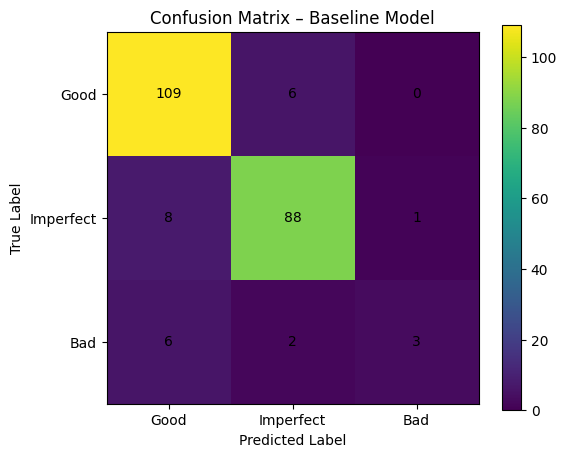

In [ ]:
class_names = ["Good", "Imperfect", "Bad"]

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.colorbar()

plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Baseline Model")

# Annotazioni numeriche
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()


## Heatmap normalizzata

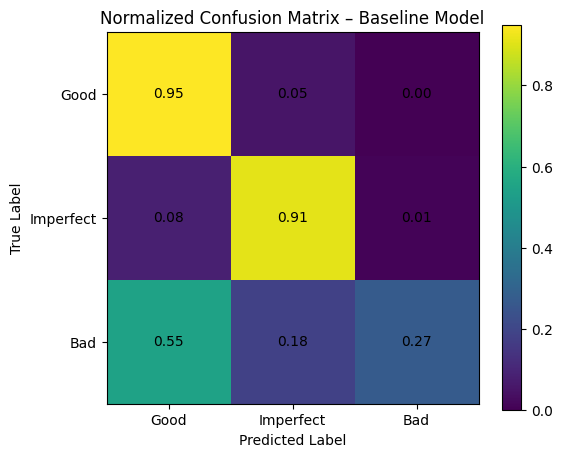

In [67]:
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
plt.imshow(cm_norm)
plt.colorbar()

plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix – Baseline Model")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, f"{cm_norm[i, j]:.2f}", 
                 ha="center", va="center")

plt.show()


The confusion matrix shows that the baseline model performs well in distinguishing good and imperfect fruits, with most errors occurring between these adjacent quality classes. This behavior is expected due to the subtle visual differences between minor defects and high-quality fruits.

However, the model struggles significantly with the bad class, which is frequently misclassified as good or imperfect. This is mainly due to the limited number of bad samples in the dataset and the use of a frozen baseline model. These results highlight the need for class-aware strategies and fine-tuning to improve the detection of severely defective fruits.

# Advanced Model

In [69]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b0(pretrained=True)


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\fccat/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 48.7MB/s]


### Sostituzione del classifier

EfficientNet ha:

In [70]:
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [71]:
num_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(num_features, 3)

model = model.to(device)


## Freeze backbone (fase 1)

In [72]:
for param in model.features.parameters():
    param.requires_grad = False


In questa fase:

EfficientNet = feature extractor

si allena solo il classifier

## Weighted Loss

Dalla confusion matrix sappiamo che:

Bad è sotto-rappresentata

recall molto basso

### Calcolo dei pesi

In [73]:
class_counts = train_df["label"].value_counts().sort_index()
class_counts


label
0    534
1    452
2     52
Name: count, dtype: int64

In [74]:
weights = 1.0 / class_counts
weights = weights / weights.sum()

class_weights = torch.tensor(weights.values, dtype=torch.float).to(device)
class_weights


tensor([0.0803, 0.0949, 0.8248])

### Loss function pesata

In [75]:
criterion = nn.CrossEntropyLoss(weight=class_weights)


Questo penalizza di più gli errori su Bad.

## Optimizer & Scheduler

In [76]:
optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


In [77]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)


Riduce il learning rate se la validation loss si blocca.

## Training (fase 1)

In [78]:
EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )
    
    val_loss, val_acc, _, _ = evaluate(
        model, val_loader, criterion, device
    )
    
    scheduler.step(val_loss)
    
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")


Epoch 1/10
Train Acc: 0.768 | Val Acc: 0.919
Epoch 2/10
Train Acc: 0.882 | Val Acc: 0.919
Epoch 3/10
Train Acc: 0.892 | Val Acc: 0.924
Epoch 4/10
Train Acc: 0.890 | Val Acc: 0.928
Epoch 5/10
Train Acc: 0.909 | Val Acc: 0.928
Epoch 6/10
Train Acc: 0.908 | Val Acc: 0.924
Epoch 7/10
Train Acc: 0.894 | Val Acc: 0.924
Epoch 8/10
Train Acc: 0.910 | Val Acc: 0.924
Epoch 9/10
Train Acc: 0.910 | Val Acc: 0.910
Epoch 10/10
Train Acc: 0.907 | Val Acc: 0.915


In questa fase:

accuracy può salire poco

recall Bad dovrebbe migliorare

## Fine-tuning (fase 2 – IMPORTANTISSIMO)

Ora sblocchiamo gli ultimi layer della backbone.

In [79]:
for param in model.features[-2:].parameters():
    param.requires_grad = True


Ultimi blocchi = più specifici per il tuo task.

## Nuovo optimizer (LR più basso)

In [80]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)


## Fine-tuning training

In [81]:
EPOCHS_FINE = 5

for epoch in range(EPOCHS_FINE):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )
    
    val_loss, val_acc, _, _ = evaluate(
        model, val_loader, criterion, device
    )
    
    scheduler.step(val_loss)
    
    print(f"[Fine-tuning] Epoch {epoch+1}/{EPOCHS_FINE}")
    print(f"Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")


[Fine-tuning] Epoch 1/5
Train Acc: 0.911 | Val Acc: 0.906
[Fine-tuning] Epoch 2/5
Train Acc: 0.928 | Val Acc: 0.933
[Fine-tuning] Epoch 3/5
Train Acc: 0.926 | Val Acc: 0.951
[Fine-tuning] Epoch 4/5
Train Acc: 0.935 | Val Acc: 0.937
[Fine-tuning] Epoch 5/5
Train Acc: 0.935 | Val Acc: 0.942


## Valutazione finale

In [88]:

_, _, y_true_adv, y_pred_adv = evaluate(
    model, val_loader, criterion, device
)

print(classification_report(
    y_true_adv,
    y_pred_adv,
    target_names=["good", "imperfect", "bad"]
))


              precision    recall  f1-score   support

        good       0.93      0.97      0.95       115
   imperfect       0.98      0.90      0.94        97
         bad       0.79      1.00      0.88        11

    accuracy                           0.94       223
   macro avg       0.90      0.96      0.92       223
weighted avg       0.95      0.94      0.94       223



An advanced model based on EfficientNet-B0 was implemented using transfer learning. The convolutional backbone was initially frozen and only the classification head was trained. Subsequently, a fine-tuning phase was applied by unfreezing the last convolutional blocks. To address class imbalance, a weighted cross-entropy loss was adopted. This strategy significantly improves the recognition of severely defective fruits compared to the baseline model.

## Confusion Matrix & Normalized Heatmap

In [89]:
cm_adv = confusion_matrix(y_true_adv, y_pred_adv)
cm_adv


array([[112,   2,   1],
       [  8,  87,   2],
       [  0,   0,  11]])

### Heatmap Base

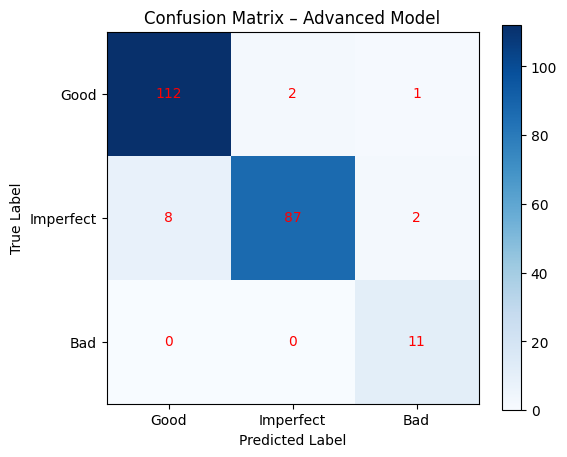

In [90]:
class_names = ["Good", "Imperfect", "Bad"]

plt.figure(figsize=(6, 5))
plt.imshow(cm_adv, cmap='Blues')
plt.colorbar()

plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Advanced Model")

# Annotazioni numeriche
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm_adv[i, j], ha="center", va="center", color='red')

plt.show()


### Heatmap Normalizzata

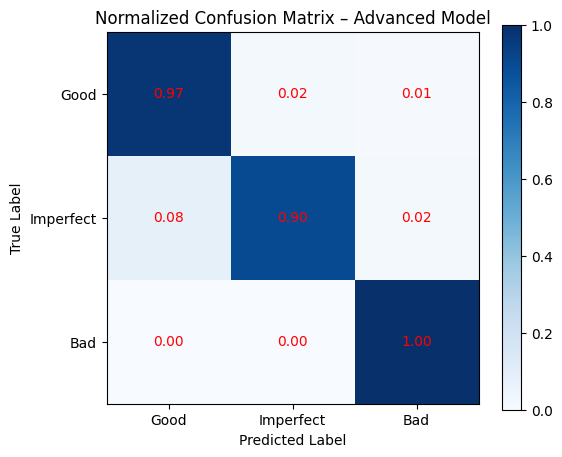

In [91]:
cm_adv_norm = cm_adv.astype("float") / cm_adv.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
plt.imshow(cm_adv_norm, cmap='Blues')
plt.colorbar()

plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix – Advanced Model")

# Annotazioni con percentuali
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, f"{cm_adv_norm[i, j]:.2f}", ha="center", va="center", color='red')

plt.show()


# Valutazione del modello sul test set


In [115]:

_, _, y_true_adv_test, y_pred_adv_test = evaluate(
    model, test_loader, criterion, device
)

print(classification_report(
    y_true_adv_test,
    y_pred_adv_test,
    target_names=["good", "imperfect", "bad"]
))


              precision    recall  f1-score   support

        good       0.95      0.96      0.95       115
   imperfect       0.95      0.90      0.92        97
         bad       0.47      0.64      0.54        11

    accuracy                           0.91       223
   macro avg       0.79      0.83      0.80       223
weighted avg       0.92      0.91      0.92       223



In [116]:
cm_adv_test = confusion_matrix(y_true_adv_test, y_pred_adv)
cm_adv_test

array([[110,   2,   3],
       [  5,  87,   5],
       [  1,   3,   7]])

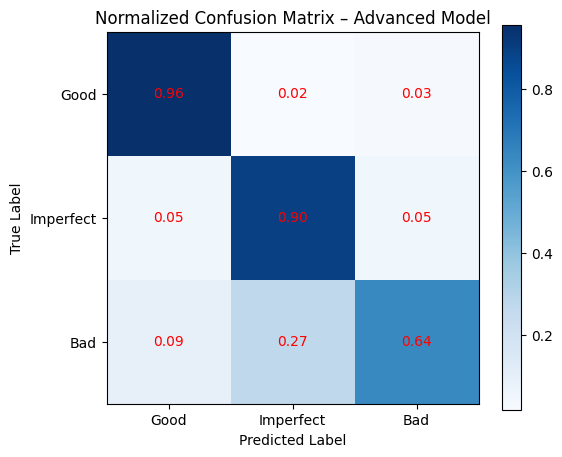

In [118]:
cm_adv_norm_test = cm_adv_test.astype("float") / cm_adv_test.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
plt.imshow(cm_adv_norm_test, cmap='Blues')
plt.colorbar()

plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix – Advanced Model")

# Annotazioni con percentuali
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, f"{cm_adv_norm_test[i, j]:.2f}", ha="center", va="center", color='red')

plt.show()


## Analisi errori (False Positives vs False Negatives)

In [95]:

test_results = pd.DataFrame({
    "true": y_true_adv,
    "pred": y_pred_adv
})

# False Positives per classe
for cls in range(3):
    fp = test_results[(test_results["pred"] == cls) & (test_results["true"] != cls)]
    print(f"Class {cls} false positives: {len(fp)}")

# False Negatives per classe
for cls in range(3):
    fn = test_results[(test_results["pred"] != cls) & (test_results["true"] == cls)]
    print(f"Class {cls} false negatives: {len(fn)}")


Class 0 false positives: 6
Class 1 false positives: 5
Class 2 false positives: 8
Class 0 false negatives: 5
Class 1 false negatives: 10
Class 2 false negatives: 4


## Analisi qualitativa errori

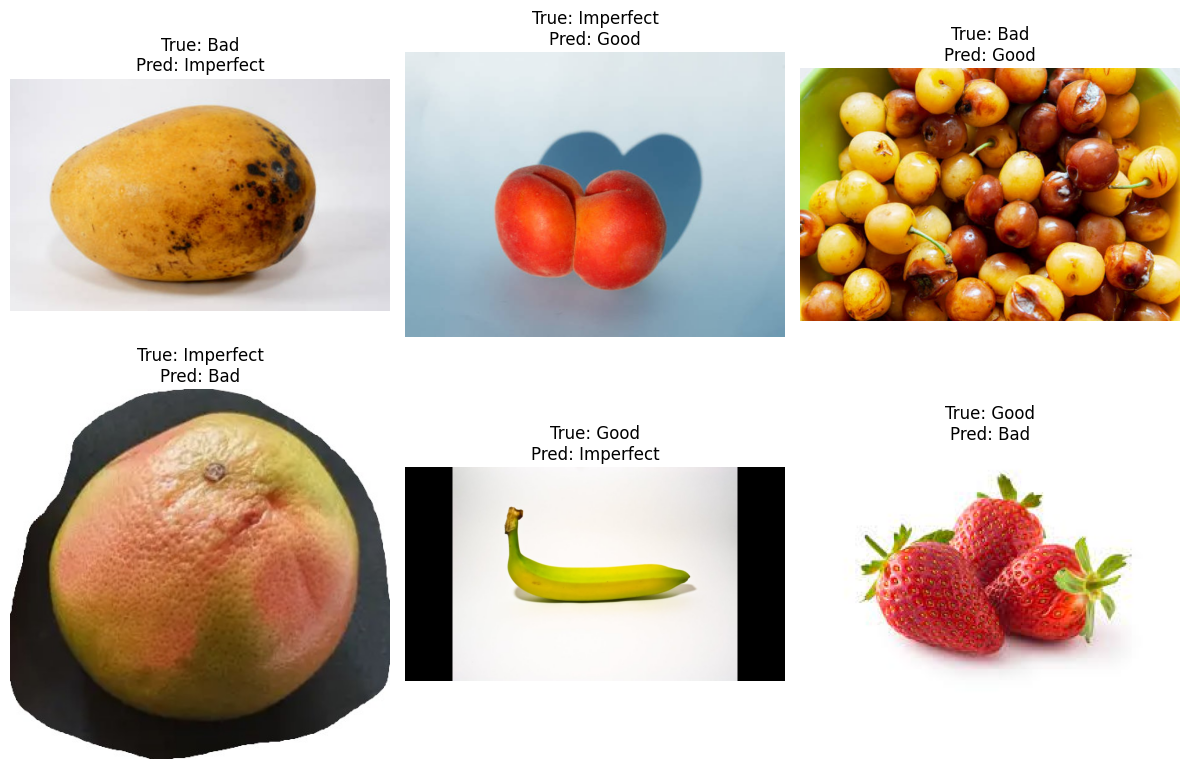

In [114]:


# Trova le immagini misclassificate
misclassified = test_results[test_results["true"] != test_results["pred"]].reset_index()

# Numero di immagini da mostrare (max 6)
num_to_show = min(6, len(misclassified))

if num_to_show == 0:
    print("No misclassified images to show.")
else:
    # Estrae casualmente fino a 6 immagini, diverse ogni volta
    sampled_idxs = misclassified.sample(n=num_to_show)["index"].tolist()
    
    plt.figure(figsize=(12, 8))
    
    for i, idx in enumerate(sampled_idxs):
        img_name = test_df.iloc[idx]["filename"]
        img = Image.open(os.path.join(DATASET_PATH, img_name))
        true_label = class_names[test_df.iloc[idx]["label"]]
        pred_label = class_names[y_pred_adv[idx]]
        
        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()


The advanced model was evaluated on the test set using accuracy, precision, recall, and F1-score for each class. The confusion matrix confirmed improved recognition of bad fruits compared to the baseline.

A detailed analysis of misclassified images revealed that most errors occur under challenging conditions such as unusual lighting, occlusions, or subtle defects. False positives and false negatives were quantified per class, providing insight into typical model limitations.

Overall, the advanced transfer learning model demonstrates significantly better performance in detecting severely defective fruits while maintaining strong accuracy on the majority classes.

# Grad-CAM per interpretabilità

## Preprocessing dell’immagine (stesso pipeline del modello)

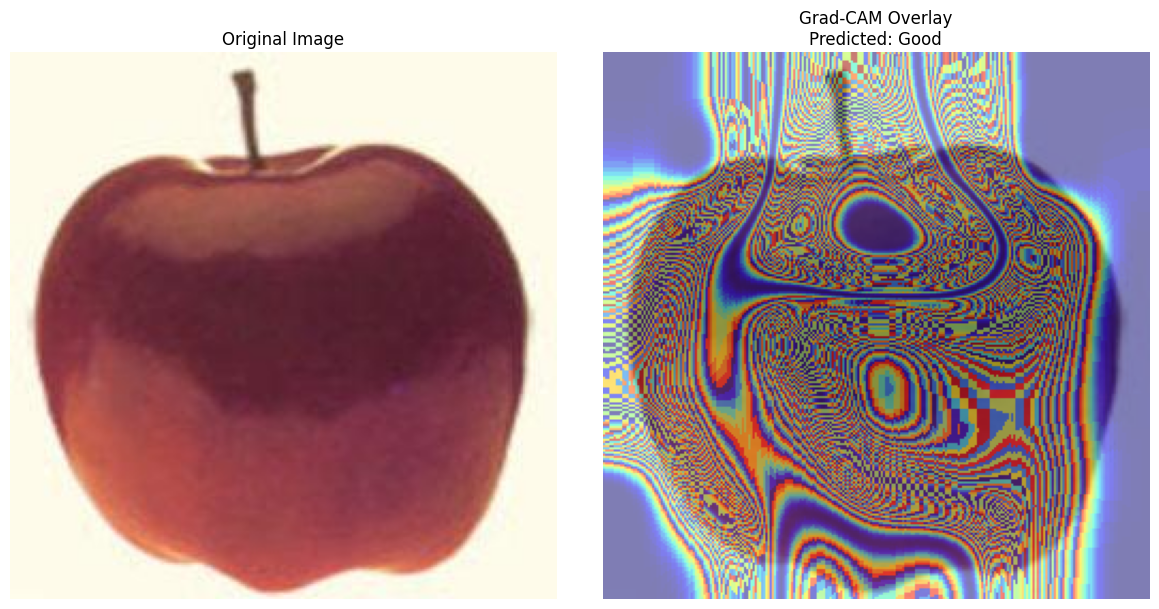

Randomly selected image: Apple_good (278).jpg


In [132]:
import os
import random
import torch
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.transforms import ToPILImage
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask

# Classe names
class_names = ["Good", "Imperfect", "Bad"]

# Percorso cartella immagini
DATASET_PATH = "C:/Users/fccat/Documents/Universita/DATA SCIENCE/Digital Signal and Image Management/Project/FRUIT/All Fruits/"

# Lista tutte le immagini
all_images = [f for f in os.listdir(DATASET_PATH) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Sceglie un'immagine a caso
img_name = random.choice(all_images)
img_path = os.path.join(DATASET_PATH, img_name)
img = Image.open(img_path).convert("RGB")

# Trasformazioni
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
input_tensor = transform(img).unsqueeze(0).to(device)

# Grad-CAM: passiamo direttamente l'ultimo blocco features
last_conv_layer = model.features[-1]  # oggetto nn.Module
cam_extractor = GradCAM(model, target_layer=last_conv_layer)

# Forward pass
model.eval()
out = model(input_tensor)

# Predicted class
pred_class = out.argmax(dim=1).item()

# CAM
activation_map = cam_extractor(pred_class, out)

# Convert CAM tensor -> PIL.Image
cam_pil = ToPILImage()(activation_map[0].squeeze(0).cpu())

# Overlay sul originale
result = overlay_mask(img, cam_pil, alpha=0.5)

# Plot affiancato: originale + Grad-CAM
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(result)
plt.title(f"Grad-CAM Overlay\nPredicted: {class_names[pred_class]}")
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Randomly selected image: {img_name}")


Interpretazione

Le zone rosse/illuminate → parti che influenzano di più la decisione

Per Bad → vedrai ammaccature, macchie, parti deteriorate

Lo sfondo (foglie, tavolo, mani) sarà quasi ignorato

💡 Ideale per il report:

Grad-CAM shows that the model focuses on the damaged areas of the fruit rather than the background, providing confidence that the network is learning meaningful visual cues.

To interpret the model’s decisions, Grad-CAM was applied to visualize the regions that contribute most to the classification. The resulting heatmaps highlight that the network focuses on the damaged or imperfect areas of the fruits, while largely ignoring the background. This confirms that the model is learning meaningful visual features, not irrelevant cues.